In [24]:
############ import modules ########

#torch modules
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
from pyro.infer.autoguide import init_to_value
# backend modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
import time
# Import adaptive sampling utility
from adaptive_data_sampling import AdaptiveDataSampler
# Import the model
from bilorentzian_model_optimized import model
#set default precision 
torch.set_default_dtype(torch.float64)
print("Libraries imported successfully!")
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
######### data loading and preprocessing #########


Libraries imported successfully!


In [25]:

# Temperature array
temps_ = ['25', '30', '35', '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

# Load ODMR data
fpath = './cycle1'
df_ = pd.read_csv(fpath, sep=',', header=0)
df = df_.iloc[0:, :-1]
df.drop(columns=['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace=True)

# Extract data
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

# Scale x-axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten() * 100

# Normalize y data (baseline subtraction, sign flip, normalization)
y_esr = y_esr.apply(lambda x: x - x[:10].mean())
y_esr = -1 * y_esr
y_esr = y_esr.apply(lambda x: x / x.max())

print(f"Data loaded successfully!")
print(f"  - Frequency points: {len(x_scale)}")
print(f"  - Temperature measurements: {len(temps)}")
print(f"  - Temperatures: {temps}")

############# Define bi-Lorentzian function (numpy version for plotting purposes) ###############
def F_np(x_in, A, X, Amp, G1, G2):
    A_reshaped = A[None, :]
    X_reshaped = X[None, :]
    B_reshaped = A_reshaped + X_reshaped
    Amp_reshaped = Amp[None, :]
    G1_reshaped = G1[None, :]
    G2_reshaped = G2[None, :]
    x_in_reshaped = x_in[:, None]

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F

# Setup MCMC kernel
init_vals = {
    "A": torch.tensor(50.0),
    "X": torch.tensor(8.0),
    "gamma1": torch.tensor(8.0),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),
}

kernel = NUTS(
    model,
    jit_compile=True,
    init_strategy=init_to_value(values=init_vals),
    ignore_jit_warnings=True,
    max_tree_depth=5
)  

#

# Run MCMC on first temperature slice with FULL data
print("Running initial MCMC on first temperature slice (full data for adaptive sampling)...")
j_init = 0
y_init = y_esr.iloc[:, j_init].values

data_full = (
    torch.tensor(x_scale, dtype=torch.float64),
    torch.tensor(y_init, dtype=torch.float64)
)

Data loaded successfully!
  - Frequency points: 100
  - Temperature measurements: 12
  - Temperatures: [25. 30. 35. 40. 45. 50. 45. 40. 35. 30. 25. 20.]
Running initial MCMC on first temperature slice (full data for adaptive sampling)...


In [26]:

start_time = time.time()
pyro.clear_param_store()
posterior_init = MCMC(
    kernel,
    num_samples=100,
    warmup_steps=100,
    num_chains=1,
    disable_progbar=False,
   
)

#  initial_params=init_vals
posterior_init.run(data_full)
time_init = time.time() - start_time

# Extract samples
hmc_samples_init = {
    k: v.detach().cpu().numpy()
    for k, v in posterior_init.get_samples().items()
}

print(f"Initial MCMC completed in {time_init:.2f} seconds")
print(f"Posterior samples shape: {[(k, v.shape) for k, v in hmc_samples_init.items()]}")




Sample: 100%|██████████| 200/200 [00:06, 29.06it/s, step size=4.06e-01, acc. prob=0.965]

Initial MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]


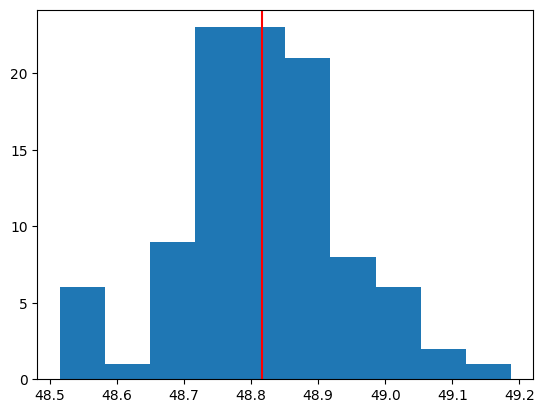

In [27]:
plt.hist(hmc_samples_init['A'], bins=10)
plt.axvline(hmc_samples_init['A'].mean(), color ='red', label = 'Mean Value')

In [28]:
 # Create sampler
sampler = AdaptiveDataSampler(x_scale, y_esr.iloc[:, j_init].values, hmc_samples_init)

# Generate adaptive sampling strategy
selected_idx, adaptive_data, stats = sampler.create_adaptive_sample(
    amplitude_threshold=0.1,     
    high_signal_fraction=1.0,    
    low_signal_fraction=0.1      
)


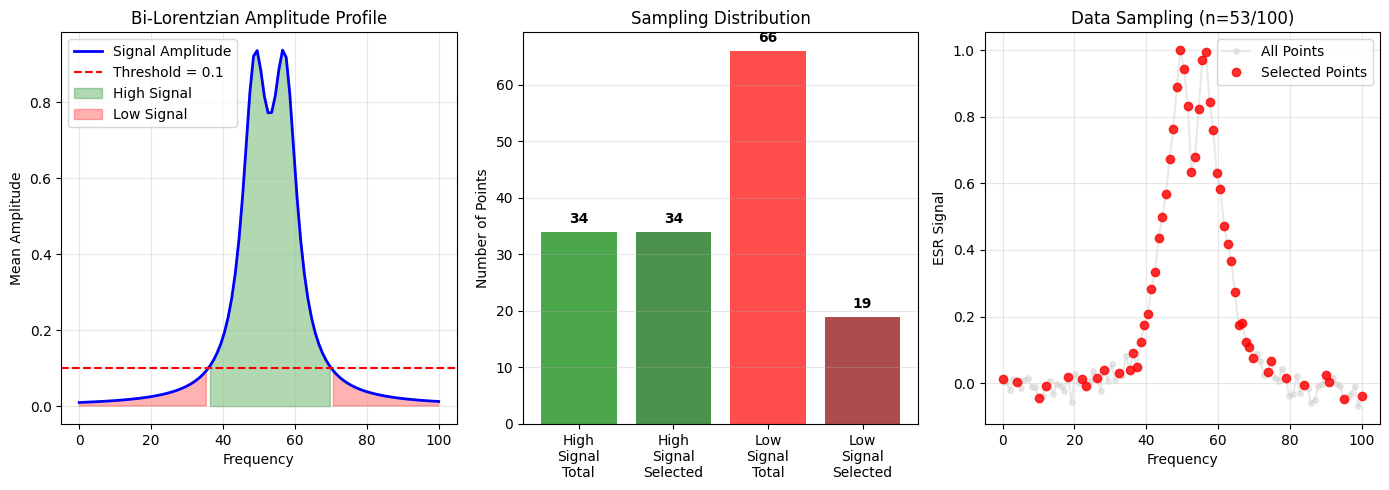

In [29]:

# Visualize
fig, axes, stats = sampler.plot_sampling_strategy(
    amplitude_threshold=0.1,
    high_signal_fraction=1.0,
    low_signal_fraction=0.3
)
plt.show()

In [30]:
# Pre-compute constants outside the loop for efficiency
# Note: Kernel must be recreated per iteration (Pyro state management with changing data shapes)
#       but init_vals and result containers are computed once

# Define initial values once (same for all iterations)
init_vals = {
    "A": torch.tensor(50.0),
    "X": torch.tensor(8.0),
    "gamma1": torch.tensor(8.0),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),
}

# Initialize result containers
idx, amp_vals, gamma1_vals, A_freq, B_freq = [], [], [], [], []
amp_var, gamma1_var, A_freq_var, B_freq_var = [], [], [], []

print("Setup complete: init values pre-computed (kernel will be created per-iteration)")

Setup complete: init values pre-computed (kernel will be created per-iteration)


  [1/12]

Sample: 100%|██████████| 200/200 [00:06, 32.38it/s, step size=4.14e-01, acc. prob=0.907]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


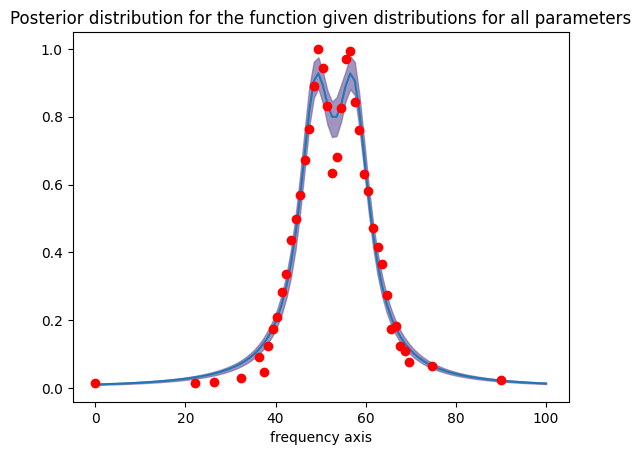

#################
  [2/12]

Sample: 100%|██████████| 200/200 [00:06, 29.42it/s, step size=3.03e-01, acc. prob=0.966]

MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


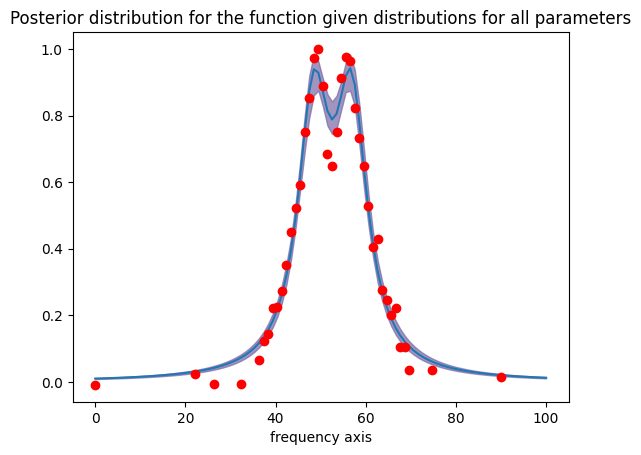

#################
  [3/12]

Sample: 100%|██████████| 200/200 [00:05, 33.85it/s, step size=7.09e-01, acc. prob=0.860]

MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


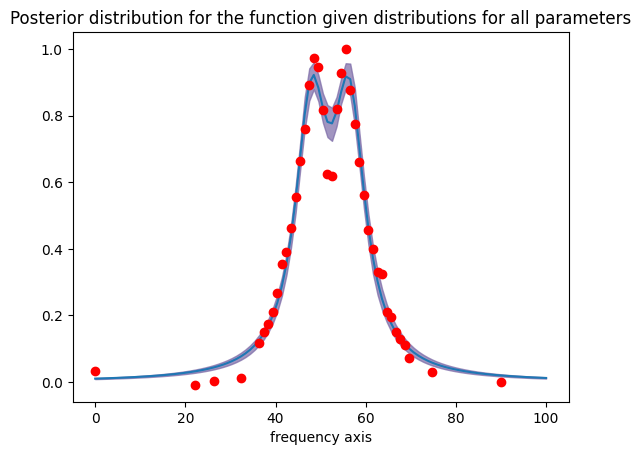

#################
  [4/12]

Sample: 100%|██████████| 200/200 [00:06, 30.79it/s, step size=4.20e-01, acc. prob=0.924]

MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


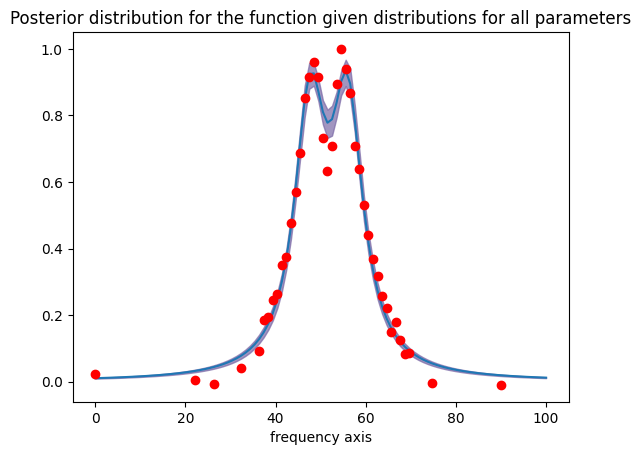

#################
  [5/12]

Sample: 100%|██████████| 200/200 [00:06, 32.40it/s, step size=4.28e-01, acc. prob=0.912]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


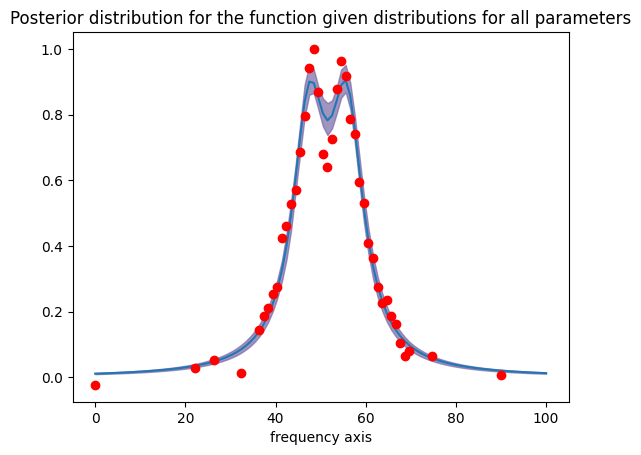

#################
  [6/12]

Sample: 100%|██████████| 200/200 [00:06, 32.66it/s, step size=4.78e-01, acc. prob=0.942]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


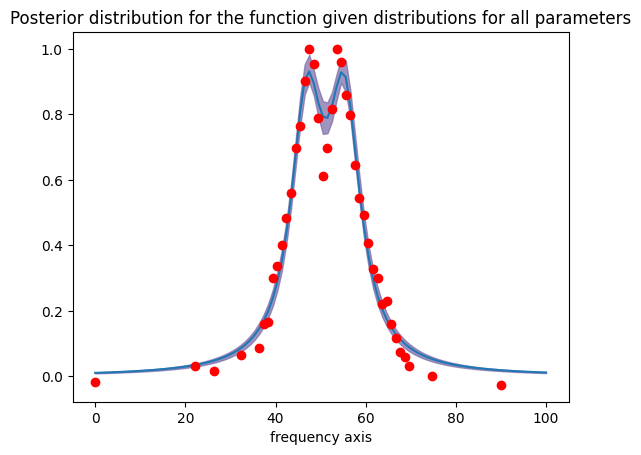

#################
  [7/12]

Sample: 100%|██████████| 200/200 [00:05, 36.60it/s, step size=5.77e-01, acc. prob=0.743]

MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


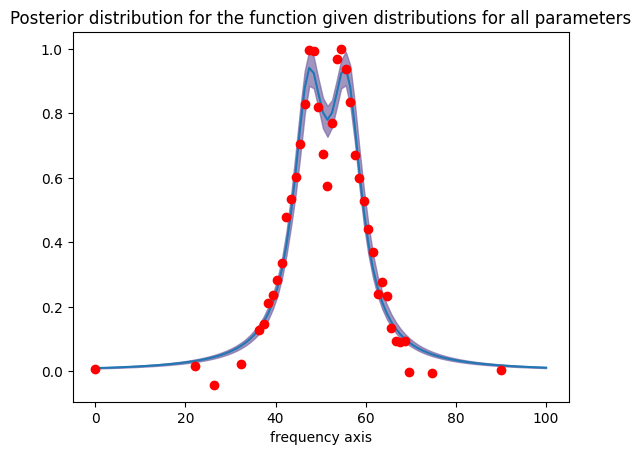

#################
  [8/12]

Sample: 100%|██████████| 200/200 [00:06, 29.77it/s, step size=2.78e-01, acc. prob=0.940]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


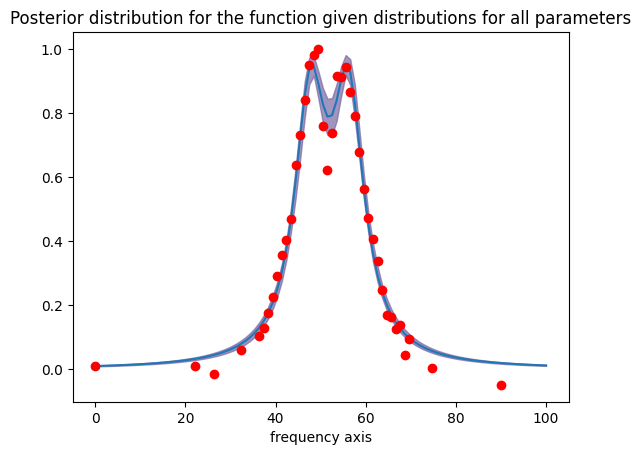

#################
  [9/12]

Sample: 100%|██████████| 200/200 [00:06, 29.65it/s, step size=4.03e-01, acc. prob=0.949]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


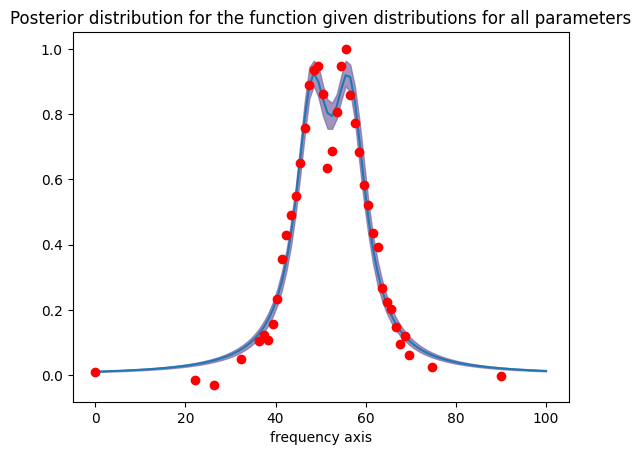

#################
  [10/12]

Sample: 100%|██████████| 200/200 [00:07, 28.08it/s, step size=2.93e-01, acc. prob=0.969]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


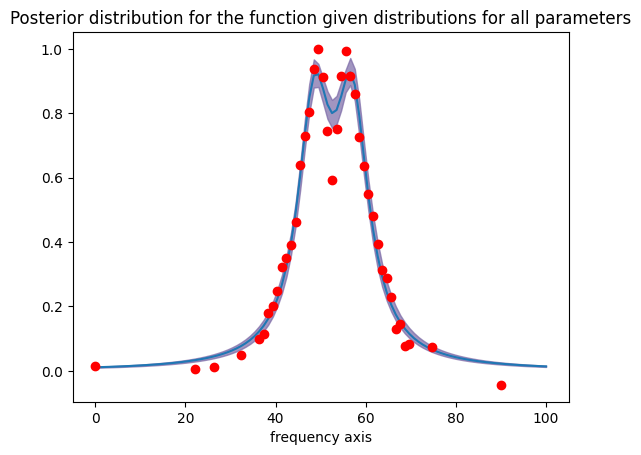

#################
  [11/12]

Sample: 100%|██████████| 200/200 [00:05, 33.38it/s, step size=5.08e-01, acc. prob=0.902]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


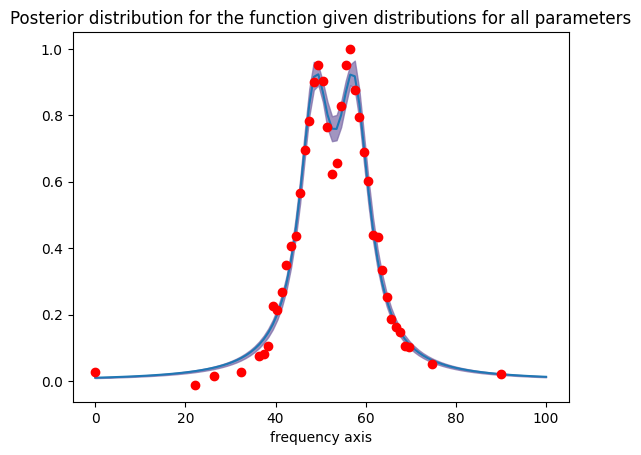

#################
  [12/12]

Sample: 100%|██████████| 200/200 [00:06, 32.71it/s, step size=6.71e-01, acc. prob=0.857]


MCMC completed in 6.89 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]
#################


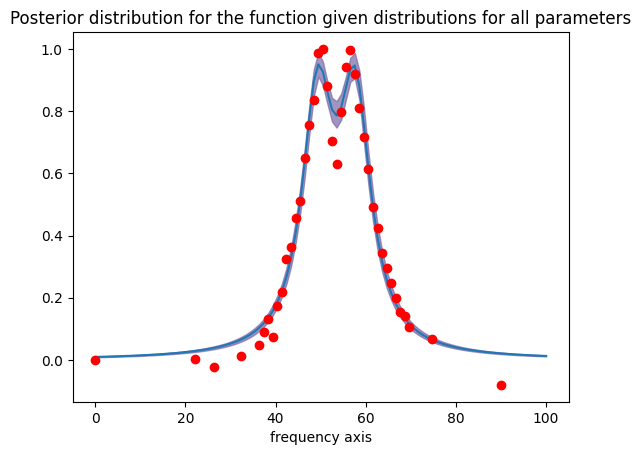

#################
total time processing all data is 77.270


In [31]:
start_time = time.time()
for num in range(0, y_esr.shape[1]):
  # Generate adaptive sampling strategy based on current temperature slice
  sampler = AdaptiveDataSampler(x_scale, y_esr.iloc[:, num].values, hmc_samples_init)
  selected_idx, adaptive_data, stats = sampler.create_adaptive_sample(
    amplitude_threshold=0.1,     
    high_signal_fraction=1.0,    
    low_signal_fraction=0.1      
    )
  
  # Extract paired adaptive x and y (compatible sizes)
  x_adaptive, y_adaptive = adaptive_data
  
  # Convert to MATCHED tensors for Pyro model
  # x_adaptive and y_adaptive have the same length from create_adaptive_sample()
  data_adaptive = (
    torch.tensor(x_adaptive, dtype=torch.float64),
    torch.tensor(y_adaptive, dtype=torch.float64)
    )
  
  print(f"  [{num+1}/{y_esr.shape[1]}]", end="", flush=True)
  
  # Clear parameter store and create fresh kernel for each iteration
  # (data shape changes between iterations due to adaptive sampling)
  pyro.clear_param_store()
  kernel_iter = NUTS(
    model,
    jit_compile=True,
    init_strategy=init_to_value(values=init_vals),
    ignore_jit_warnings=True,
    max_tree_depth=5
  )
  
  # Run MCMC with adaptive data
  posterior_adaptive = MCMC(kernel_iter, num_samples=100, warmup_steps=100, num_chains=1)
  posterior_adaptive.run(data_adaptive)
  
  # Extract samples
  hmc_samples = {
        k: v.detach().cpu().numpy()
        for k, v in posterior_adaptive.get_samples().items()
    }
  print(f"MCMC completed in {time_init:.2f} seconds")
  print(f"Posterior samples shape: {[(k, v.shape) for k, v in hmc_samples.items()]}")
  
  A_ = hmc_samples['A']  # Shape: (100,) for single chain
  X_ = hmc_samples['X']
  B_ = (A_ + X_)
  amp_ = hmc_samples['amp']
  gamma1_ = hmc_samples['gamma1']
  gamma2_ = hmc_samples['gamma1']  # Since gamma2 = gamma1 in the model
  var = hmc_samples['var']
  
  # Evaluate model on full x_scale for visualization and quantiles
  F = F_np(x_scale, A_, X_, amp_, gamma1_, gamma2_)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis=1)
  
  # Accumulate results
  idx.append(num)
  A_freq.append(A_.mean())
  B_freq.append(B_.mean())
  gamma1_vals.append(gamma1_.mean())
  amp_vals.append(amp_.mean())
  A_freq_var.append(A_.var())
  gamma1_var.append(gamma1_.var())
  amp_var.append(amp_.var())
  
  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_adaptive, y_adaptive, 'ro'); # plotting the adaptive data subset
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');
  plt.show()
  print('#################')

print(f'total time processing all data is {(time.time() -  start_time):.3f}')

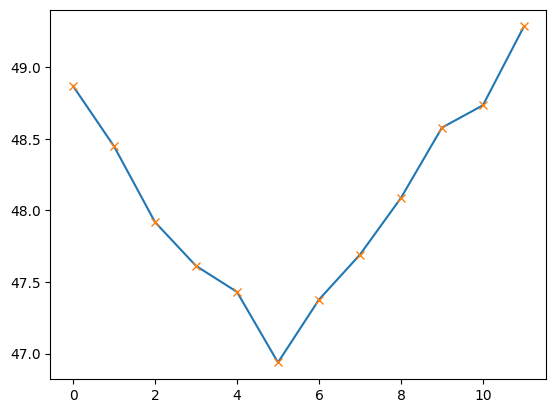

In [32]:
a_freq = np.array(A_freq)

plt.plot(a_freq)
plt.plot(a_freq, 'x')

<Axes: >

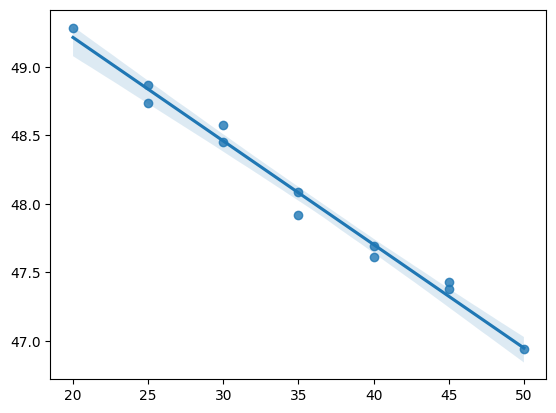

In [33]:
sns.regplot(x = temps, y = a_freq)

Testing RMSE:1.0650


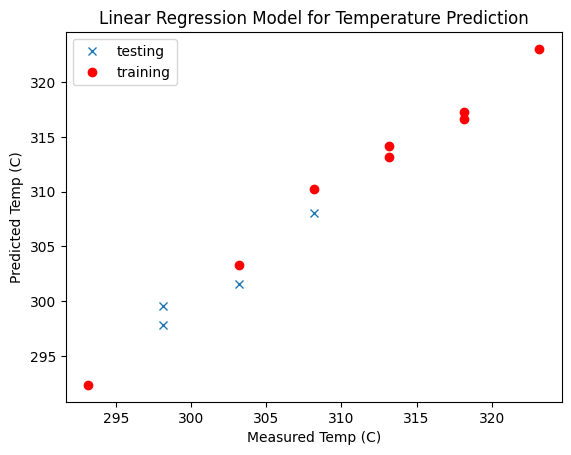

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

A_var = a_freq.reshape(-1,1)
temps = temps +273.15
x_train, x_test, y_train, y_test = train_test_split(A_var, temps, test_size=0.3, random_state=42)

ln = LinearRegression()

ln.fit(x_train, y_train)
temp_pred = ln.predict(x_test)

plt.plot(y_test, temp_pred, 'x'); plt.plot(y_train, ln.predict(x_train), 'ro')
plt.legend(['testing', 'training'])
mse = mean_squared_error(y_test, temp_pred)
print(f'Testing RMSE:{np.sqrt(mse):.4f}')
plt.xlabel('Measured Temp (C)'); plt.ylabel('Predicted Temp (C)'); plt.title('Linear Regression Model for Temperature Prediction');